# Notebook 7 - Comprehensive Model Evaluation

This is the project wrap-up notebook for supervised model comparison. The earlier notebooks each focused on one chunk. This one puts the usable models into the same evaluation frame so the final answer is not stitched together from mismatched splits and random one-off outputs.

The setup is still intentionally coursework-practical: one stratified test split, train-only scaling, consistent metrics, and enough plots to explain the model tradeoffs without creating extra files.

In [11]:
from pathlib import Path
import sys
import time
import warnings

ROOT = Path.cwd()
if not (ROOT / "features" / "features.csv").exists():
    maybe_root = ROOT.parent
    if (maybe_root / "features" / "features.csv").exists():
        ROOT = maybe_root
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    AdaBoostClassifier as SkAdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier as SkRandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB as SkGaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier as SkDecisionTreeClassifier
from xgboost import XGBClassifier

from minilearn.classifiers import (
    AdaBoostClassifier,
    DecisionTreeClassifier,
    GaussianNaiveBayes,
    KNN,
    LinearSVM,
    LogisticRegression,
    RandomForestClassifier,
)
from minilearn.preprocessing import StandardScaler, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 432
FEATURE_PATH = ROOT / "features" / "features.csv"

## Load data and keep the split honest

The metadata columns are useful for checking the dataset, but they are not model features. For supervised comparison the target is `emotion_id`; the human-readable emotion names are kept only for labels in reports and plots.

Scaling is fit on the training set only. Distance-based and linear models get scaled inputs. Trees and Naive Bayes use the raw extracted feature scale.

In [12]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)
target_names = [emotion_names[i] for i in labels]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"rows={len(df)}, features={len(feature_cols)}, classes={len(labels)}")
print(f"train={len(X_train)}, test={len(X_test)}")
print(emotion_names)

rows=2452, features=407, classes=8
train=1963, test=489
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## Model registry

This table is the contract for the notebook. Every model declares whether it wants scaled features and whether it needs any special label handling. XGBoost is the weird one because it wants labels starting at zero, so it gets shifted during fit and shifted back during prediction.

In [13]:
model_specs = [
    {
        "name": "MiniLearn Logistic Regression",
        "family": "MiniLearn linear",
        "model": LogisticRegression(learning_rate=0.08, max_iter=700, reg_strength=0.001, tol=1e-7),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "MiniLearn Gaussian NB",
        "family": "MiniLearn baseline",
        "model": GaussianNaiveBayes(),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "MiniLearn KNN",
        "family": "MiniLearn distance",
        "model": KNN(k=7, weights="distance"),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "MiniLearn Linear SVM",
        "family": "MiniLearn linear",
        "model": LinearSVM(learning_rate=0.001, max_iter=800, reg_strength=0.01, random_state=RANDOM_STATE),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "MiniLearn Decision Tree",
        "family": "MiniLearn tree",
        "model": DecisionTreeClassifier(max_depth=7, min_samples_leaf=2),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "MiniLearn Random Forest",
        "family": "MiniLearn ensemble",
        "model": RandomForestClassifier(n_estimators=16, max_depth=7, min_samples_leaf=2, max_features="sqrt", max_samples=0.85, random_state=RANDOM_STATE),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "MiniLearn AdaBoost",
        "family": "MiniLearn ensemble",
        "model": AdaBoostClassifier(n_estimators=20, learning_rate=0.65, max_depth=1, min_samples_leaf=2, random_state=RANDOM_STATE),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "sklearn Logistic Regression",
        "family": "sklearn linear",
        "model": SkLogisticRegression(max_iter=1500, C=0.5),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "sklearn Gaussian NB",
        "family": "sklearn baseline",
        "model": SkGaussianNB(),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "sklearn KNN",
        "family": "sklearn distance",
        "model": KNeighborsClassifier(n_neighbors=7, weights="distance"),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "sklearn Linear SVM",
        "family": "sklearn linear",
        "model": LinearSVC(C=0.25, max_iter=5000, random_state=RANDOM_STATE),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "sklearn RBF SVM",
        "family": "sklearn kernel",
        "model": SVC(kernel="rbf", C=10, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE),
        "scaled": True,
        "kind": "normal",
    },
    {
        "name": "sklearn Decision Tree",
        "family": "sklearn tree",
        "model": SkDecisionTreeClassifier(max_depth=7, min_samples_leaf=2, random_state=RANDOM_STATE),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "sklearn Random Forest",
        "family": "sklearn ensemble",
        "model": SkRandomForestClassifier(n_estimators=180, min_samples_leaf=2, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "sklearn AdaBoost",
        "family": "sklearn ensemble",
        "model": SkAdaBoostClassifier(estimator=SkDecisionTreeClassifier(max_depth=1, min_samples_leaf=2, random_state=RANDOM_STATE), n_estimators=80, learning_rate=0.5, random_state=RANDOM_STATE),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "sklearn Gradient Boosting",
        "family": "sklearn ensemble",
        "model": GradientBoostingClassifier(n_estimators=25, learning_rate=0.08, max_depth=2, subsample=0.85, random_state=RANDOM_STATE),
        "scaled": False,
        "kind": "normal",
    },
    {
        "name": "XGBoost",
        "family": "boosted trees",
        "model": XGBClassifier(n_estimators=90, max_depth=3, learning_rate=0.07, subsample=0.85, colsample_bytree=0.75, objective="multi:softprob", eval_metric="mlogloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=2),
        "scaled": False,
        "kind": "xgboost",
    },
]

pd.DataFrame([
    {"model": s["name"], "family": s["family"], "scaled": s["scaled"], "kind": s["kind"]}
    for s in model_specs
])

,model,family,scaled,kind
0,MiniLearn Logistic Regression,MiniLearn linear,True,normal
1,MiniLearn Gaussian NB,MiniLearn baseline,False,normal
2,MiniLearn KNN,MiniLearn distance,True,normal
3,MiniLearn Linear SVM,MiniLearn linear,True,normal
4,MiniLearn Decision Tree,MiniLearn tree,False,normal
5,MiniLearn Random Forest,MiniLearn ensemble,False,normal
6,MiniLearn AdaBoost,MiniLearn ensemble,False,normal
7,sklearn Logistic Regression,sklearn linear,True,normal
8,sklearn Gaussian NB,sklearn baseline,False,normal
9,sklearn KNN,sklearn distance,True,normal


## Fit and score every model

Accuracy is easy to read, but macro F1 is more useful here because each emotion deserves equal attention. Weighted F1 is still included because it shows the performance after accounting for the natural class counts.

In [14]:
fitted = {}
predictions = {}
rows = []

for spec in model_specs:
    name = spec["name"]
    model = spec["model"]
    Xtr = X_train_s if spec["scaled"] else X_train
    Xte = X_test_s if spec["scaled"] else X_test
    ytr = y_train - 1 if spec["kind"] == "xgboost" else y_train

    print(f"fitting {name}...")
    start = time.perf_counter()
    model.fit(Xtr, ytr)
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    pred = model.predict(Xte)
    predict_seconds = time.perf_counter() - start
    if spec["kind"] == "xgboost":
        pred = pred + 1

    fitted[name] = {**spec, "model": model}
    predictions[name] = pred
    rows.append({
        "model": name,
        "family": spec["family"],
        "scaled": spec["scaled"],
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    })

results = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
show_cols = ["model", "family", "accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]
results_display = results[show_cols].copy()
results_display[["accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]] = results_display[["accuracy", "macro_f1", "weighted_f1", "fit_seconds", "predict_seconds"]].round(4)
results_display

fitting MiniLearn Logistic Regression...
fitting MiniLearn Gaussian NB...
fitting MiniLearn KNN...
fitting MiniLearn Linear SVM...
fitting MiniLearn Decision Tree...
fitting MiniLearn Random Forest...
fitting MiniLearn AdaBoost...
fitting sklearn Logistic Regression...
fitting sklearn Gaussian NB...
fitting sklearn KNN...
fitting sklearn Linear SVM...
fitting sklearn RBF SVM...
fitting sklearn Decision Tree...
fitting sklearn Random Forest...
fitting sklearn AdaBoost...
fitting sklearn Gradient Boosting...
fitting XGBoost...


,model,family,accuracy,macro_f1,weighted_f1,fit_seconds,predict_seconds
0,sklearn RBF SVM,sklearn kernel,0.8037,0.7928,0.8024,0.4421,0.1582
1,sklearn Linear SVM,sklearn linear,0.7198,0.7037,0.7199,1.4907,0.0007
2,sklearn Logistic Regression,sklearn linear,0.6953,0.6824,0.6952,15.9981,0.0014
3,MiniLearn Logistic Regression,MiniLearn linear,0.6892,0.6816,0.6877,1.1466,0.0005
4,XGBoost,boosted trees,0.6667,0.6588,0.6647,6.1447,0.0051
5,sklearn Random Forest,sklearn ensemble,0.6687,0.6479,0.6658,0.9177,0.0894
6,MiniLearn KNN,MiniLearn distance,0.6524,0.6302,0.6514,0.0000,1.2357
7,sklearn KNN,sklearn distance,0.6524,0.6302,0.6514,0.0057,0.0569
8,MiniLearn Linear SVM,MiniLearn linear,0.5971,0.5912,0.5957,6.9135,0.0003
9,sklearn Gradient Boosting,sklearn ensemble,0.5644,0.5491,0.5608,20.3563,0.0021


## Leaderboard plot

The shape here is more important than one exact decimal. The stronger nonlinear models should rise to the top because SER has awkward feature interactions: energy, pitch-ish spectral measures, and MFCC summaries do not separate emotions cleanly with one straight line.

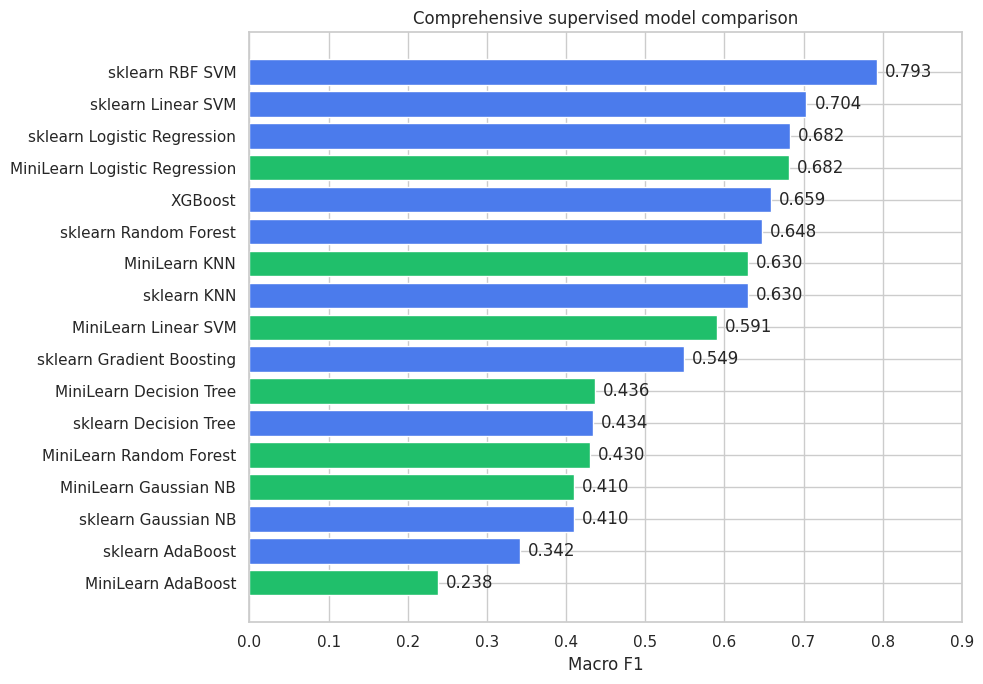

In [15]:
plot_df = results_display.sort_values("macro_f1", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(plot_df["model"].str.startswith("MiniLearn"), "#20bf6b", "#4b7bec")
ax.barh(plot_df["model"], plot_df["macro_f1"], color=colors)
ax.set_xlabel("Macro F1")
ax.set_title("Comprehensive supervised model comparison")
ax.set_xlim(0, max(0.9, plot_df["macro_f1"].max() + 0.08))
for i, value in enumerate(plot_df["macro_f1"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

## Best overall model and best MiniLearn model

This is the comparison I would use in the final presentation: the best production-style model versus the best from-scratch model. The gap is expected. MiniLearn is proving understanding, while sklearn/XGBoost are optimized implementations with more mature training behavior.

In [16]:
best_overall = results.iloc[0]["model"]
best_minilearn = results[results["model"].str.startswith("MiniLearn")].iloc[0]["model"]
print("Best overall:", best_overall)
print("Best MiniLearn:", best_minilearn)

for name in [best_overall, best_minilearn]:
    print("\n" + "=" * 72)
    print(name)
    print(classification_report(y_test, predictions[name], labels=labels, target_names=target_names, zero_division=0))

Best overall: sklearn RBF SVM
Best MiniLearn: MiniLearn Logistic Regression

sklearn RBF SVM
              precision    recall  f1-score   support

     neutral       0.75      0.79      0.77        38
        calm       0.89      0.96      0.92        75
       happy       0.79      0.81      0.80        75
         sad       0.74      0.73      0.74        75
       angry       0.86      0.85      0.86        75
     fearful       0.76      0.77      0.77        75
     disgust       0.72      0.76      0.74        38
   surprised       0.89      0.63      0.74        38

    accuracy                           0.80       489
   macro avg       0.80      0.79      0.79       489
weighted avg       0.81      0.80      0.80       489


MiniLearn Logistic Regression
              precision    recall  f1-score   support

     neutral       0.65      0.63      0.64        38
        calm       0.74      0.85      0.80        75
       happy       0.76      0.68      0.72        75
        

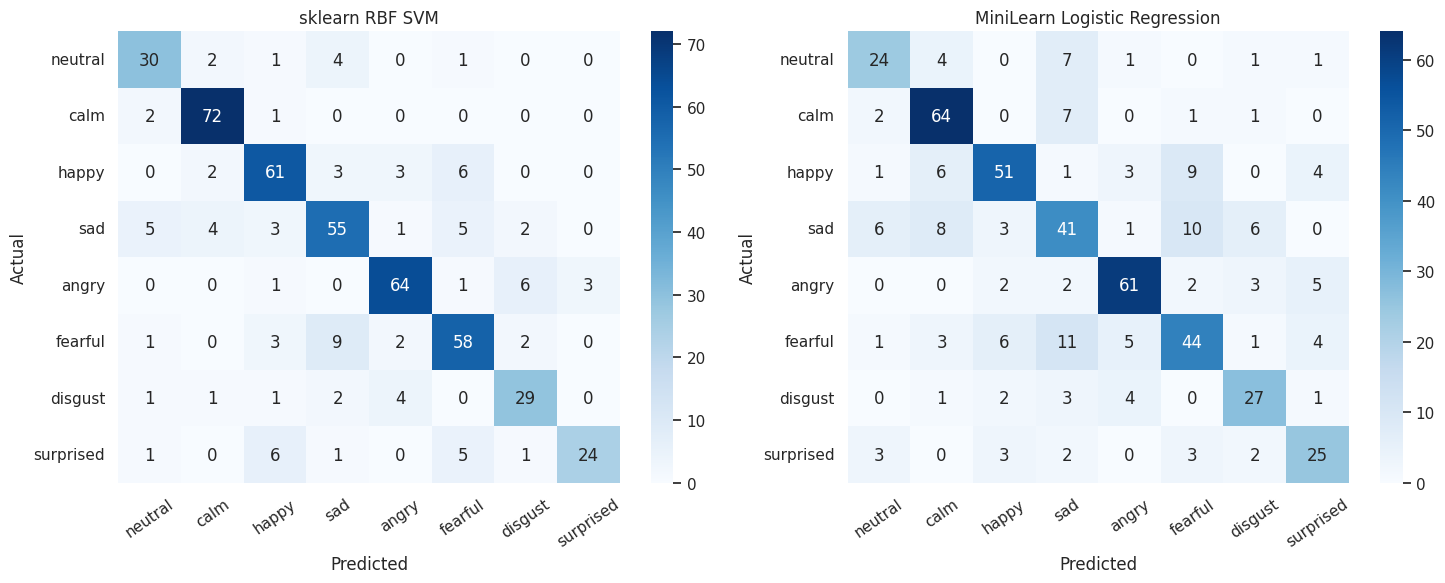

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, name in zip(axes, [best_overall, best_minilearn]):
    cm = confusion_matrix(y_test, predictions[name], labels=labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

## Per-class F1 for the best model

This plot is more useful than only saying the final model got around a certain accuracy. It shows which emotions are actually being separated well and which ones are carrying the mistakes.

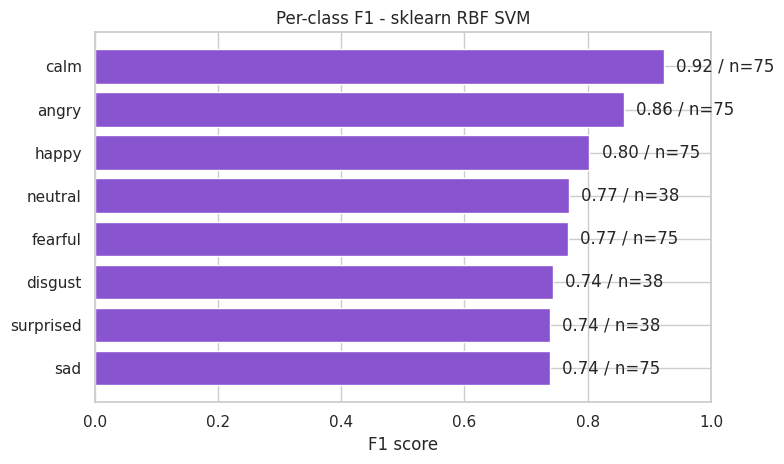

,emotion,f1,support
1,calm,0.923077,75.0
4,angry,0.859060,75.0
2,happy,0.802632,75.0
0,neutral,0.769231,38.0
5,fearful,0.768212,75.0
6,disgust,0.743590,38.0
7,surprised,0.738462,38.0
3,sad,0.738255,75.0


In [18]:
best_report = classification_report(
    y_test,
    predictions[best_overall],
    labels=labels,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)
per_class = pd.DataFrame([
    {"emotion": emotion, "f1": best_report[emotion]["f1-score"], "support": best_report[emotion]["support"]}
    for emotion in target_names
]).sort_values("f1", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(per_class["emotion"], per_class["f1"], color="#8854d0")
ax.set_xlabel("F1 score")
ax.set_title(f"Per-class F1 - {best_overall}")
ax.set_xlim(0, 1)
for i, row in enumerate(per_class.itertuples(index=False)):
    ax.text(row.f1 + 0.02, i, f"{row.f1:.2f} / n={int(row.support)}", va="center")
plt.tight_layout()
plt.show()
per_class.sort_values("f1", ascending=False)

## ROC/AUC for top models

ROC/AUC is a one-vs-rest view in this multiclass setup. It asks whether the model gives the true class higher scores than competing classes across thresholds. This is not a replacement for F1, but it helps explain model ranking when the predicted label alone hides score confidence.

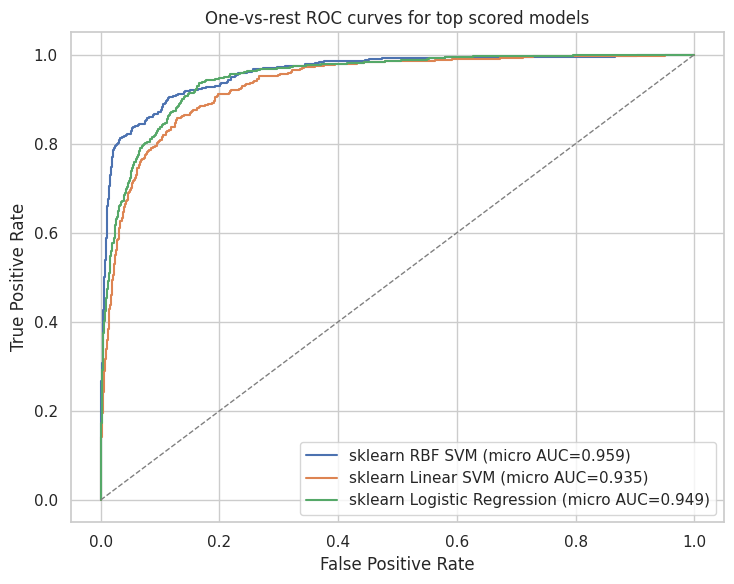

,model,macro_auc_ovr,micro_auc_ovr
0,sklearn RBF SVM,0.9576,0.9595
1,sklearn Linear SVM,0.9289,0.9350
2,sklearn Logistic Regression,0.9454,0.9487


In [21]:
def score_matrix(name):
    spec = fitted[name]
    model = spec["model"]
    Xte = X_test_s if spec["scaled"] else X_test
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(Xte)
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(Xte)
    else:
        return None
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 2 or scores.shape[1] != len(labels):
        return None
    return scores

candidate_names = []
for name in results["model"]:
    scores = score_matrix(name)
    if scores is not None:
        candidate_names.append(name)
    if len(candidate_names) == 3:
        break

y_test_bin = label_binarize(y_test, classes=labels)
roc_rows = []
fig, ax = plt.subplots(figsize=(7.5, 6))
for name in candidate_names:
    scores = score_matrix(name)
    macro_auc = roc_auc_score(y_test_bin, scores, average="macro", multi_class="ovr")
    micro_fpr, micro_tpr, _ = roc_curve(y_test_bin.ravel(), scores.ravel())
    micro_auc = auc(micro_fpr, micro_tpr)
    roc_rows.append({"model": name, "macro_auc_ovr": macro_auc, "micro_auc_ovr": micro_auc})
    ax.plot(micro_fpr, micro_tpr, label=f"{name} (micro AUC={micro_auc:.3f})")

ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("One-vs-rest ROC curves for top scored models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame(roc_rows).round(4)

## Feature importance from the strongest tree models

The exact feature ordering should not be overclaimed, but it is useful for sanity. If the best tree models are mostly using spectral and MFCC summary features, that matches the feature extraction design.

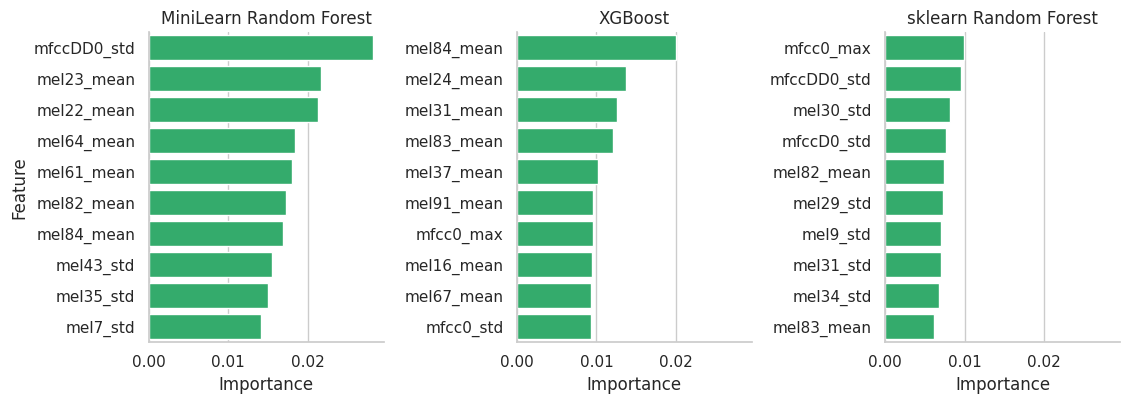

,model,feature,importance
918,MiniLearn Random Forest,mfccDD0_std,0.028128
978,MiniLearn Random Forest,mel23_mean,0.021674
977,MiniLearn Random Forest,mel22_mean,0.021265
1019,MiniLearn Random Forest,mel64_mean,0.018345
1016,MiniLearn Random Forest,mel61_mean,0.018019
1037,MiniLearn Random Forest,mel82_mean,0.017222
1039,MiniLearn Random Forest,mel84_mean,0.016888
1126,MiniLearn Random Forest,mel43_std,0.015485
1118,MiniLearn Random Forest,mel35_std,0.014993
1090,MiniLearn Random Forest,mel7_std,0.014093


In [20]:
importance_sources = []
for name in ["sklearn Random Forest", "XGBoost", "MiniLearn Random Forest"]:
    if name in fitted and hasattr(fitted[name]["model"], "feature_importances_"):
        vals = fitted[name]["model"].feature_importances_
        importance_sources.append(pd.DataFrame({"model": name, "feature": feature_cols, "importance": vals}))

importance_df = pd.concat(importance_sources, ignore_index=True)
top_importance = importance_df.sort_values(["model", "importance"], ascending=[True, False]).groupby("model").head(10)

g = sns.catplot(
    data=top_importance,
    y="feature",
    x="importance",
    col="model",
    kind="bar",
    sharey=False,
    height=4.2,
    aspect=0.9,
    color="#20bf6b",
)
g.set_titles("{col_name}")
g.set_axis_labels("Importance", "Feature")
plt.tight_layout()
plt.show()
top_importance

## Final interpretation

- The final ranking is the honest project answer because every model used the same split and target.
- Macro F1 is the main ranking metric because it keeps small/harder emotion classes from getting washed out.
- Scaling mattered most for KNN, logistic regression, and SVM. Tree models did not need it because they split by thresholds.
- Single trees were useful for visualization, but ensembles were stronger because they reduce variance or correct earlier mistakes.
- XGBoost and Random Forest are the practical winners for this feature table. MiniLearn models are still valuable because they show the machinery underneath the library versions.
- The remaining limitation is that these are clip-level summary features. A temporal model might capture emotion dynamics better, but that is beyond the current MiniLearn scope.